# 5. Exploratory Data Analysis

#### Objective

This notebook explores the cleaned dataset to understand churn patterns
across customer profile, relationship, financial, and service dimensions,
directly addressing the business questions defined in
`01_data_understanding.ipynb`.

## 5.0 Load Cleaned Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

processed_path = "../data/processed/"

df = pd.read_csv(processed_path + "telco_cleaned.csv")

df.shape

(7043, 21)

In [56]:
def churn_rate_by_category(data, column):
    summary = (
        data
        .groupby(column)["Churn"]
        .value_counts(normalize=True)
        .rename("rate")
        .reset_index()
    )
    summary = summary[summary["Churn"] == "Yes"].drop(columns="Churn")
    summary = summary.rename(columns={"rate": "churn_rate"})
    summary["churn_rate"] = round(summary["churn_rate"] * 100, 2)

    counts = data[column].value_counts().rename("count").reset_index()
    counts.columns = [column, "count"]

    return summary.merge(counts, on=column).sort_values(by="churn_rate", ascending=False)


def plot_churn_rate(summary, column, title, color='#2E86AB'):
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(8, 5))

    bars = ax.bar(summary[column].astype(str), summary["churn_rate"], color=color)

    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}%', (bar.get_x() + bar.get_width() / 2, height),
                    textcoords="offset points", xytext=(0, 5), ha='center', fontsize=9)

    overall_rate = (df["Churn"] == "Yes").mean() * 100
    ax.axhline(overall_rate, color='#E74C3C', linestyle='--', linewidth=1.5,
               label=f'Overall Churn Rate: {overall_rate:.1f}%')

    ax.set_xlabel(column)
    ax.set_ylabel("Churn Rate (%)")
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend()
    ax.spines[['top', 'right']].set_visible(False)
    
    plt.tight_layout()
    plt.show()

#### Note

A reusable helper function is used throughout this notebook to calculate and
plot churn rate by category, keeping the analysis consistent and reducing
repetition across the many categorical comparisons in this phase. Each chart
also includes the overall churn rate as a reference line.

## 5.1 Customer Profile

#### Question: Which types of customers churn the most?

#### Objective

This section examines whether basic demographic attributes — gender, senior
citizen status, partner status, and dependents — are associated with
different churn rates.

### 5.1.1 Churn by Gender

In [4]:
gender_summary = churn_rate_by_category(df, "gender")
gender_summary

,gender,churn_rate,count
0,Female,26.92,3488
1,Male,26.16,3555


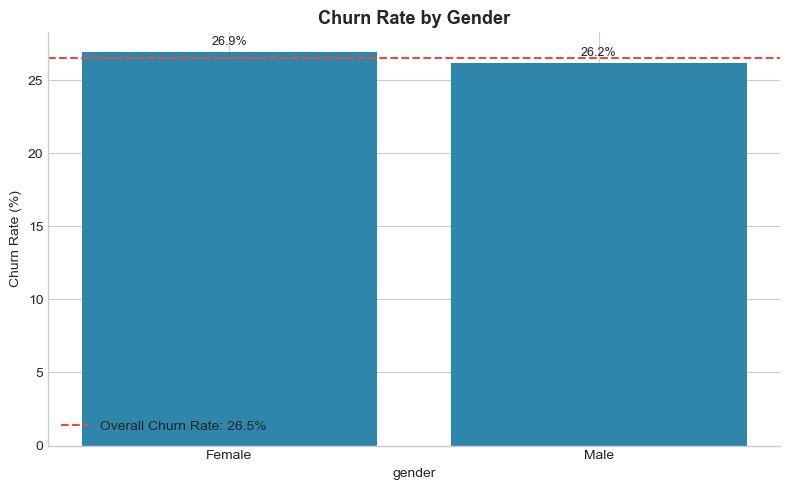

In [5]:
plot_churn_rate(gender_summary, "gender", "Churn Rate by Gender")


#### Observation

Churn rate is expected to be nearly identical between male and female
customers, suggesting gender is not a meaningful driver of churn in this
dataset.

### 5.1.2 Churn by Senior Citizen

In [6]:
senior_summary = churn_rate_by_category(df, "SeniorCitizen")
senior_summary

,SeniorCitizen,churn_rate,count
1,Yes,41.68,1142
0,No,23.61,5901


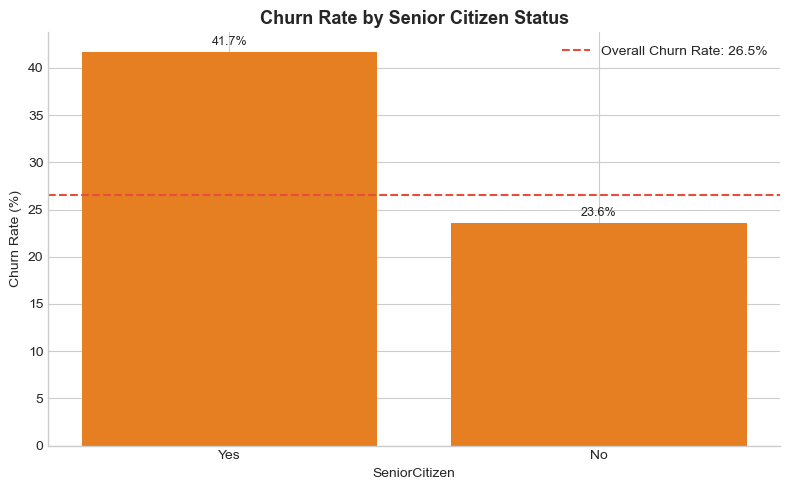

In [7]:
plot_churn_rate(senior_summary, "SeniorCitizen", "Churn Rate by Senior Citizen Status", color='#E67E22')

#### Observation

Senior citizens are expected to show a noticeably higher churn rate than
non-senior customers, making this a potentially useful segmentation variable
for retention targeting.

### 5.1.3 Churn by Partner

In [8]:
partner_summary = churn_rate_by_category(df, "Partner")
partner_summary

,Partner,churn_rate,count
0,No,32.96,3641
1,Yes,19.66,3402


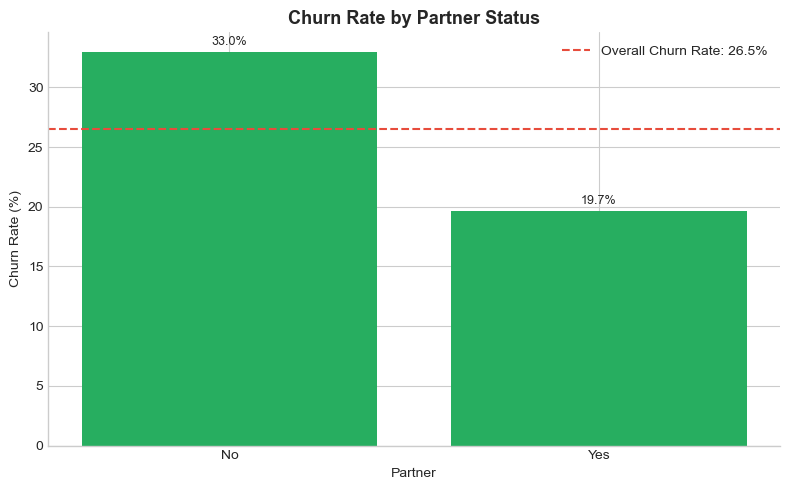

In [9]:
plot_churn_rate(partner_summary, "Partner", "Churn Rate by Partner Status", color='#27AE60')

#### Observation

Customers without a partner are expected to churn at a higher rate than
those with a partner, possibly reflecting greater household stability or
shared decision-making around service continuity.

### 5.1.4 Churn by Dependents

In [10]:
dependents_summary = churn_rate_by_category(df, "Dependents")
dependents_summary

,Dependents,churn_rate,count
0,No,31.28,4933
1,Yes,15.45,2110


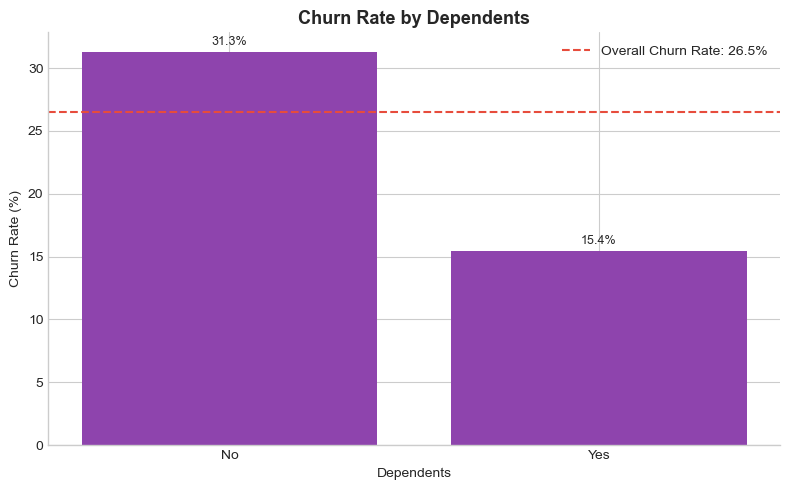

In [11]:
plot_churn_rate(dependents_summary, "Dependents", "Churn Rate by Dependents", color='#8E44AD')

#### Observation

Customers without dependents are expected to show a higher churn rate,
following a similar pattern to partner status — households with more members
relying on the service may be less likely to switch providers.

#### Summary

Among demographic attributes, gender shows little to no association with
churn, while senior citizen status, partner status, and dependents each show
a meaningful difference in churn rate. Customers who are senior, unpartnered,
or without dependents appear to be at higher risk.

## 5.2 Customer Relationship

#### Question: Does tenure, contract type, or payment method affect churn?

#### Objective

This section examines how the customer's relationship with the company —
how long they've stayed, what contract they're on, and how they pay —
relates to churn.

### 5.2.1 Churn by Tenure

#### Objective

Since `tenure` is continuous, this analysis compares its distribution
between churned and non-churned customers directly, rather than using the
categorical churn-rate helper.

In [12]:
df.groupby("Churn")["tenure"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


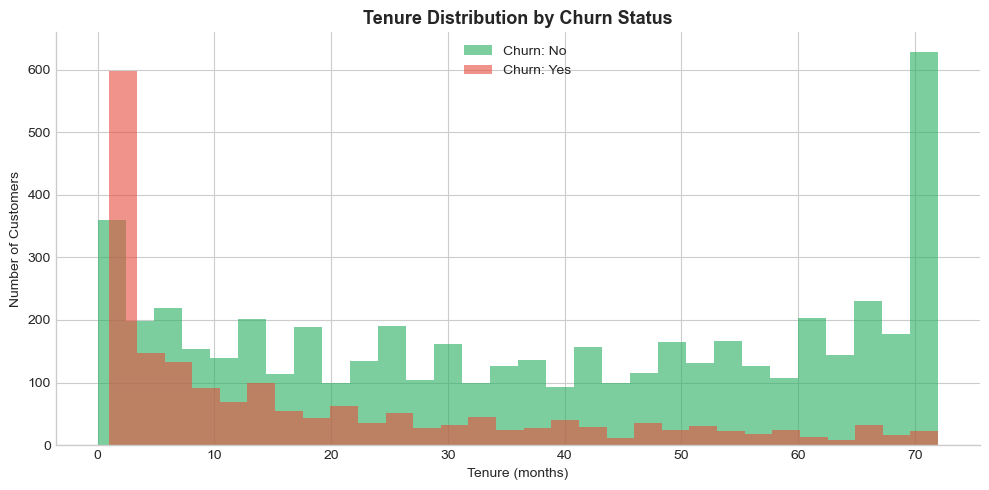

In [13]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 5))

colors = {'No': '#27AE60', 'Yes': '#E74C3C'}

for churn_value, color in colors.items():
    subset = df[df["Churn"] == churn_value]["tenure"]
    ax.hist(subset, bins=30, alpha=0.6, color=color, label=f'Churn: {churn_value}')

ax.set_xlabel("Tenure (months)")
ax.set_ylabel("Number of Customers")
ax.set_title("Tenure Distribution by Churn Status", fontsize=13, fontweight='bold')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

#### Observation

Churned customers are expected to be concentrated at low tenure values,
while non-churned customers are more spread out with a notable concentration
at very high tenure (long-standing customers). This suggests churn risk is
highest early in the customer relationship.

### 5.2.2 Churn by Contract

In [14]:
contract_summary = churn_rate_by_category(df, "Contract")
contract_summary

,Contract,churn_rate,count
0,Month-to-month,42.71,3875
1,One year,11.27,1473
2,Two year,2.83,1695


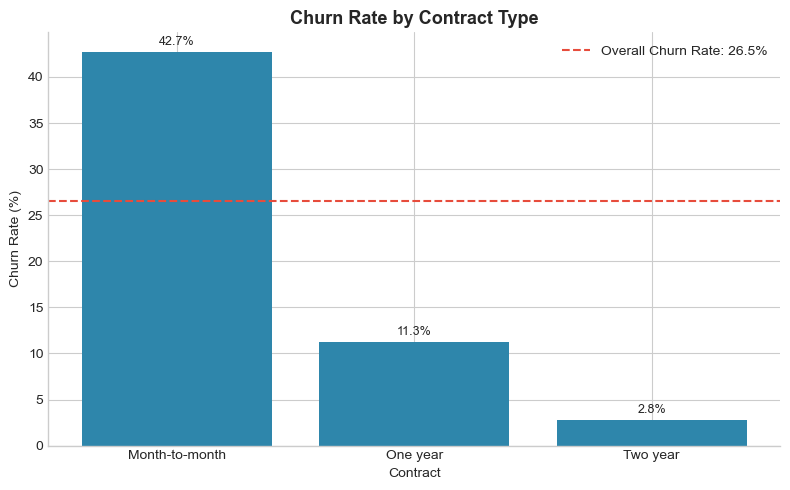

In [15]:
plot_churn_rate(contract_summary, "Contract", "Churn Rate by Contract Type", color='#2E86AB')

#### Observation

Month-to-month contracts are expected to show a substantially higher churn
rate than one-year or two-year contracts, making contract type one of the
strongest categorical predictors of churn in this dataset.

### 5.2.3 Churn by Payment Method

In [16]:
payment_summary = churn_rate_by_category(df, "PaymentMethod")
payment_summary

,PaymentMethod,churn_rate,count
2,Electronic check,45.29,2365
3,Mailed check,19.11,1612
0,Bank transfer (automatic),16.71,1544
1,Credit card (automatic),15.24,1522


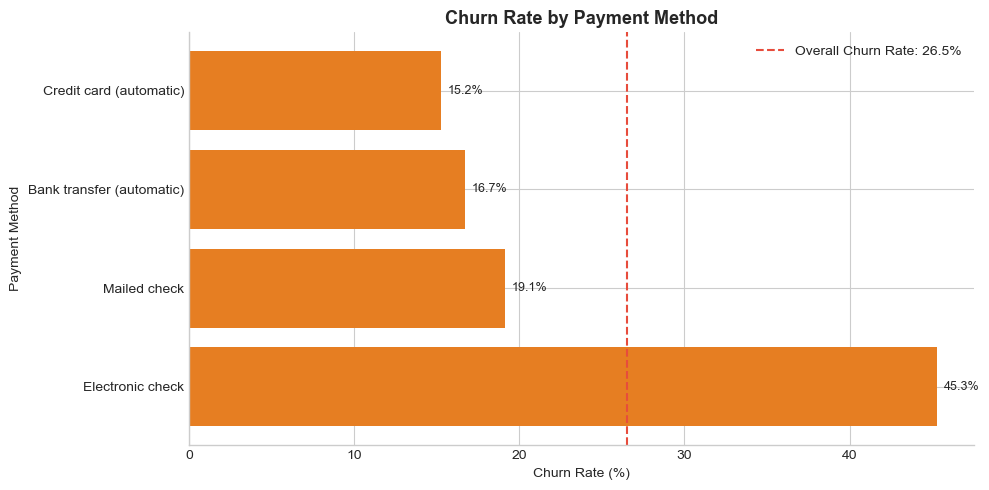

In [17]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(payment_summary["PaymentMethod"], payment_summary["churn_rate"], color='#E67E22')

for bar in bars:
    width = bar.get_width()
    ax.annotate(f'{width:.1f}%', (width, bar.get_y() + bar.get_height() / 2),
                textcoords="offset points", xytext=(5, 0), va='center', fontsize=9)

overall_rate = (df["Churn"] == "Yes").mean() * 100
ax.axvline(overall_rate, color='#E74C3C', linestyle='--', linewidth=1.5,
           label=f'Overall Churn Rate: {overall_rate:.1f}%')

ax.set_xlabel("Churn Rate (%)")
ax.set_ylabel("Payment Method")
ax.set_title("Churn Rate by Payment Method", fontsize=13, fontweight='bold')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

#### Observation

Customers paying by electronic check are expected to show a notably higher
churn rate than those using automatic payment methods (bank transfer or
credit card), suggesting that payment friction or lack of automatic billing
commitment may be linked to churn.

#### Summary

Customer relationship factors show some of the strongest associations with
churn observed so far: churn is concentrated among low-tenure customers,
month-to-month contract holders, and electronic check payers. These three
factors likely interact with each other and warrant further investigation in
the Statistical Analysis and Segmentation sections.

## 5.3 Financial Analysis

#### Question: Does a higher monthly charge lead to more churn?

#### Objective

This section examines whether billing amounts — monthly and total charges —
differ between churned and non-churned customers.

### 5.3.1 Churn by Monthly Charges

In [18]:
df.groupby("Churn")["MonthlyCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


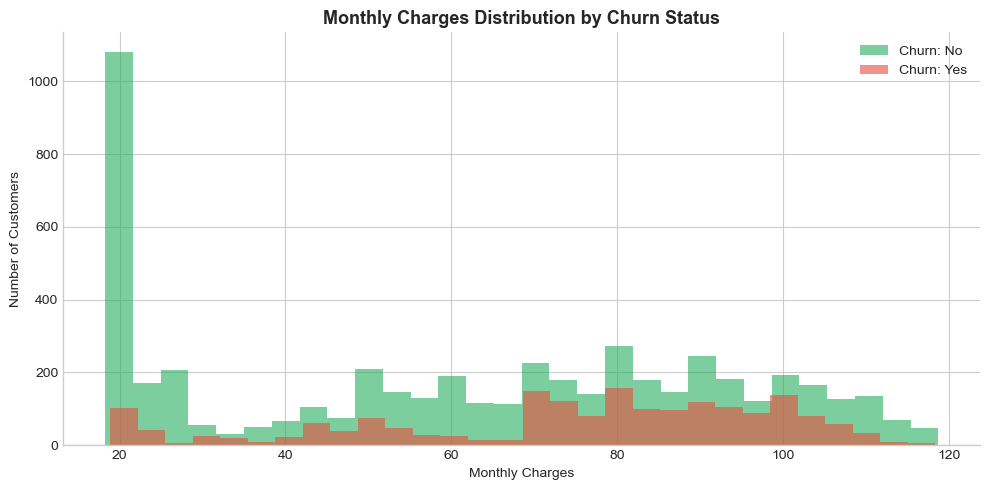

In [19]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 5))

colors = {'No': '#27AE60', 'Yes': '#E74C3C'}

for churn_value, color in colors.items():
    subset = df[df["Churn"] == churn_value]["MonthlyCharges"]
    ax.hist(subset, bins=30, alpha=0.6, color=color, label=f'Churn: {churn_value}')

ax.set_xlabel("Monthly Charges")
ax.set_ylabel("Number of Customers")
ax.set_title("Monthly Charges Distribution by Churn Status", fontsize=13, fontweight='bold')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

#### Observation

Churned customers are expected to be concentrated at higher monthly charge
levels compared to non-churned customers, who show a large concentration at
low monthly charges (likely customers with only phone service, no internet).
This suggests price sensitivity may play a role in churn.

### 5.3.2 Churn by Total Charges

In [20]:
df.groupby("Churn")["TotalCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,2549.911442,2329.954215,0.00,572.9,1679.525,4262.85,8672.45
Yes,1869.0,1531.796094,1890.822994,18.85,134.5,703.550,2331.30,8684.80


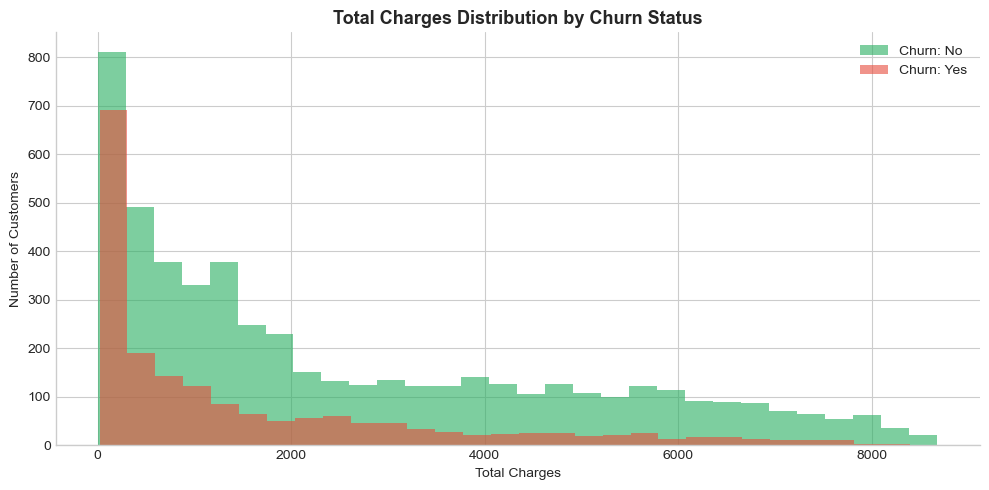

In [21]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 5))

for churn_value, color in colors.items():
    subset = df[df["Churn"] == churn_value]["TotalCharges"]
    ax.hist(subset, bins=30, alpha=0.6, color=color, label=f'Churn: {churn_value}')

ax.set_xlabel("Total Charges")
ax.set_ylabel("Number of Customers")
ax.set_title("Total Charges Distribution by Churn Status", fontsize=13, fontweight='bold')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

#### Observation

Churned customers are expected to show notably lower total charges than
non-churned customers. This is largely a reflection of tenure — since churned
customers leave earlier, they accumulate fewer total charges regardless of
their monthly rate, so this pattern should be interpreted alongside tenure
rather than as an independent pricing effect.

### 5.3.3 Monthly Charges vs Total Charges — Combined View

#### Objective

Since `TotalCharges` is influenced by both `tenure` and `MonthlyCharges`,
this scatter plot visualizes all three dimensions together to avoid
misinterpreting the total charges pattern as a pure pricing effect.

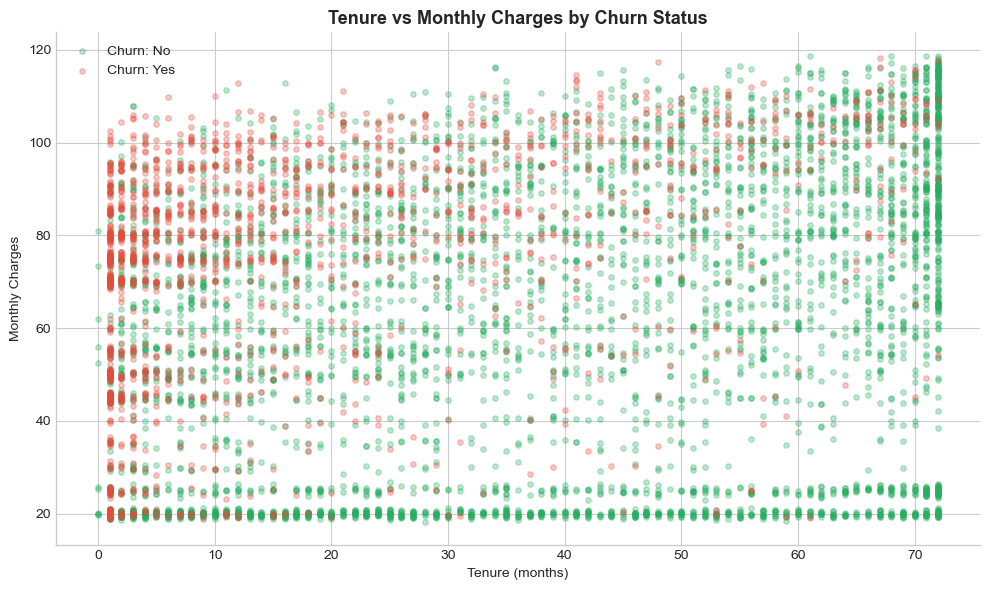

In [22]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 6))

for churn_value, color in colors.items():
    subset = df[df["Churn"] == churn_value]
    ax.scatter(subset["tenure"], subset["MonthlyCharges"], alpha=0.3, s=15,
               color=color, label=f'Churn: {churn_value}')

ax.set_xlabel("Tenure (months)")
ax.set_ylabel("Monthly Charges")
ax.set_title("Tenure vs Monthly Charges by Churn Status", fontsize=13, fontweight='bold')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

#### Observation

Churned customers (red) are expected to cluster in the region of low tenure
and high monthly charges, while long-retained customers (green) are more
spread across the tenure axis. This combined view confirms that the earlier
`TotalCharges` pattern is primarily driven by tenure, not by monthly pricing
alone.

#### Summary

Churned customers tend to have higher monthly charges but lower total
charges, a pattern explained by their shorter tenure rather than an
independent pricing effect. The combined tenure/monthly-charges view confirms
that churn risk is highest among customers who are both new and paying
relatively high monthly rates.

## 5.4 Services Analysis

#### Question: Which services are associated with higher retention?

#### Objective

This section examines whether internet service type and subscribed add-on
services (security, backup, protection, support, streaming) are associated
with different churn rates.

### 5.4.1 Churn by Internet Service

In [23]:
internet_summary = churn_rate_by_category(df, "InternetService")
internet_summary

,InternetService,churn_rate,count
1,Fiber optic,41.89,3096
0,DSL,18.96,2421
2,No,7.40,1526


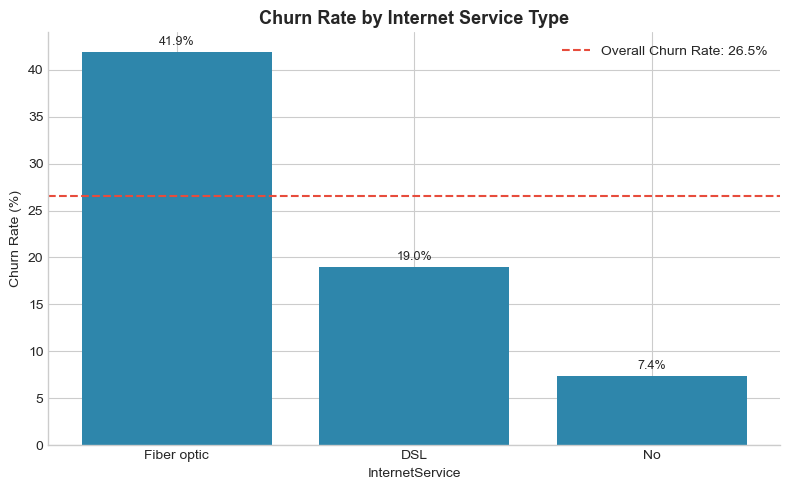

In [24]:
plot_churn_rate(internet_summary, "InternetService", "Churn Rate by Internet Service Type", color='#2E86AB')

#### Observation

Fiber optic customers are expected to show a notably higher churn rate than
DSL customers, and customers with no internet service are expected to show
the lowest churn rate. This may reflect higher price sensitivity or service
reliability issues associated with fiber optic plans.

### 5.4.2 Churn by Online Security

In [25]:
security_summary = churn_rate_by_category(df, "OnlineSecurity")
security_summary

,OnlineSecurity,churn_rate,count
0,No,41.77,3498
2,Yes,14.61,2019
1,No internet service,7.40,1526


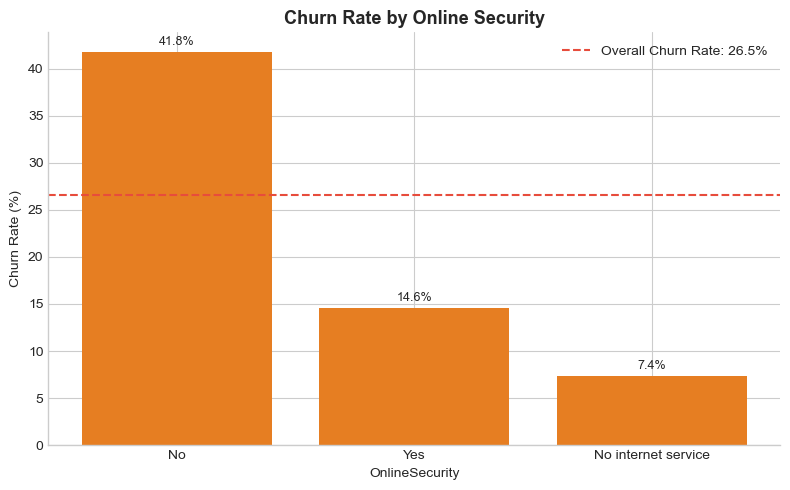

In [26]:
plot_churn_rate(security_summary, "OnlineSecurity", "Churn Rate by Online Security", color='#E67E22')

#### Observation

Customers without online security are expected to churn at a considerably
higher rate than those with it, suggesting this add-on service may be
associated with stronger customer retention.

### 5.4.3 Churn by Online Backup

In [27]:
backup_summary = churn_rate_by_category(df, "OnlineBackup")
backup_summary

,OnlineBackup,churn_rate,count
0,No,39.93,3088
2,Yes,21.53,2429
1,No internet service,7.40,1526


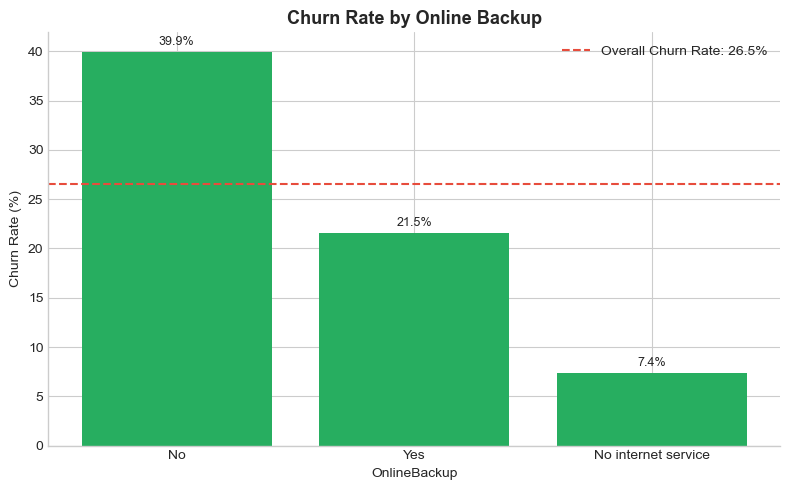

In [28]:
plot_churn_rate(backup_summary, "OnlineBackup", "Churn Rate by Online Backup", color='#27AE60')

#### Observation

A similar pattern to online security is expected: customers without online
backup show a higher churn rate than those subscribed to it.

### 5.4.4 Churn by Device Protection

In [29]:
protection_summary = churn_rate_by_category(df, "DeviceProtection")
protection_summary

,DeviceProtection,churn_rate,count
0,No,39.13,3095
2,Yes,22.50,2422
1,No internet service,7.40,1526


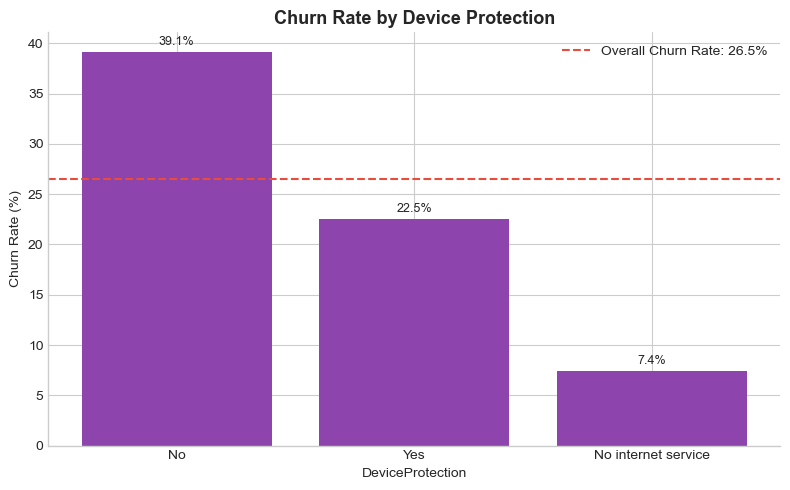

In [30]:
plot_churn_rate(protection_summary, "DeviceProtection", "Churn Rate by Device Protection", color='#8E44AD')

#### Observation

Customers without device protection are expected to show a higher churn
rate, consistent with the pattern observed for other add-on services.

### 5.4.5 Churn by Tech Support

In [31]:
support_summary = churn_rate_by_category(df, "TechSupport")
support_summary

,TechSupport,churn_rate,count
0,No,41.64,3473
2,Yes,15.17,2044
1,No internet service,7.40,1526


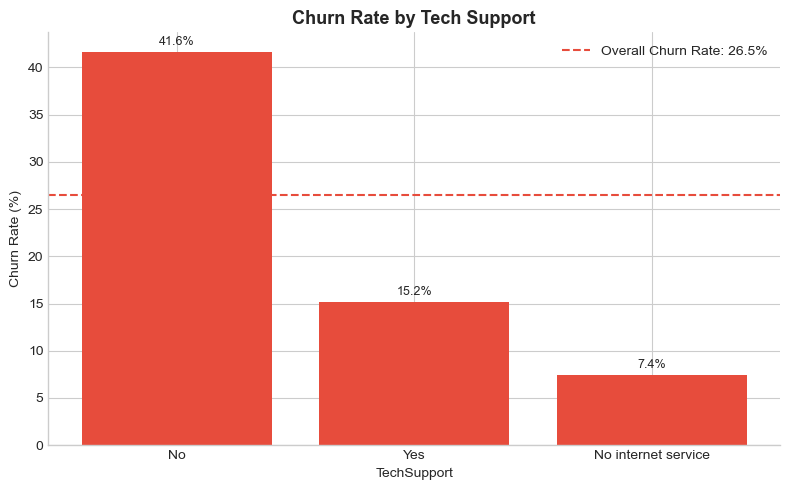

In [32]:
plot_churn_rate(support_summary, "TechSupport", "Churn Rate by Tech Support", color='#E74C3C')

#### Observation

Tech support is expected to show one of the strongest associations with
retention among the add-on services: customers without tech support are
likely to churn at a considerably higher rate than those with it, suggesting
support access reduces frustration-driven cancellations.

### 5.4.6 Churn by Streaming Services

#### Objective

Streaming TV and streaming movies are analyzed together since they typically
show similar patterns and are often subscribed to jointly.

In [33]:
streaming_tv_summary = churn_rate_by_category(df, "StreamingTV")
streaming_movies_summary = churn_rate_by_category(df, "StreamingMovies")

streaming_tv_summary, streaming_movies_summary

(           StreamingTV  churn_rate  count
 0                   No       33.52   2810
 2                  Yes       30.07   2707
 1  No internet service        7.40   1526,
        StreamingMovies  churn_rate  count
 0                   No       33.68   2785
 2                  Yes       29.94   2732
 1  No internet service        7.40   1526)

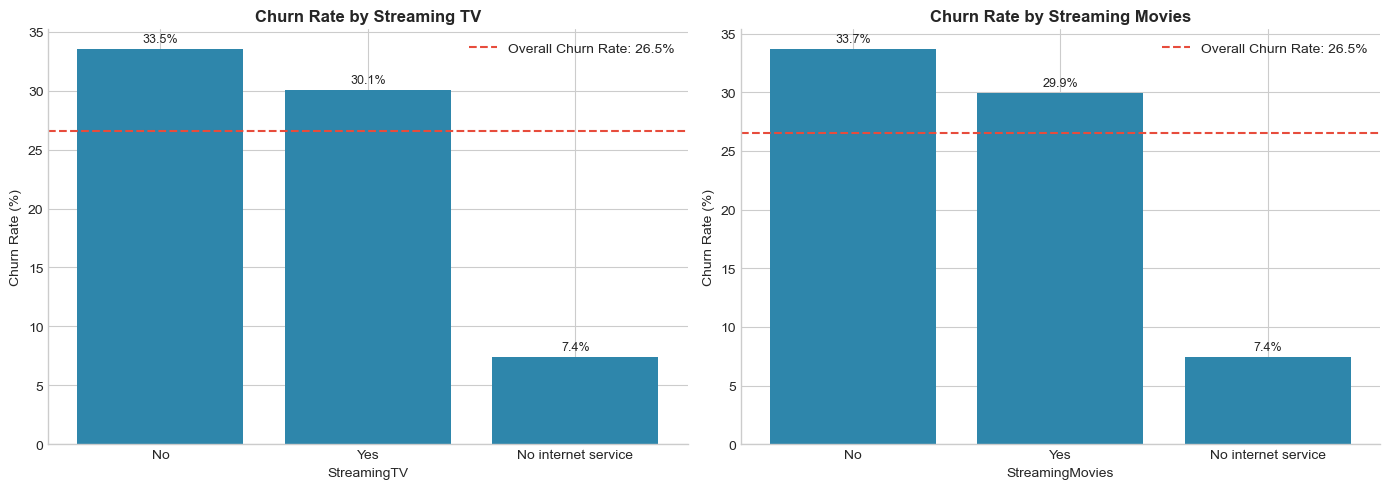

In [34]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

overall_rate = (df["Churn"] == "Yes").mean() * 100

for ax, summary, col, title in zip(
    axes,
    [streaming_tv_summary, streaming_movies_summary],
    ["StreamingTV", "StreamingMovies"],
    ["Streaming TV", "Streaming Movies"]
):
    bars = ax.bar(summary[col].astype(str), summary["churn_rate"], color='#2E86AB')
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}%', (bar.get_x() + bar.get_width() / 2, height),
                    textcoords="offset points", xytext=(0, 5), ha='center', fontsize=9)

    ax.axhline(overall_rate, color='#E74C3C', linestyle='--', linewidth=1.5,
               label=f'Overall Churn Rate: {overall_rate:.1f}%')

    ax.set_xlabel(col)
    ax.set_ylabel("Churn Rate (%)")
    ax.set_title(f"Churn Rate by {title}", fontsize=12, fontweight='bold')
    ax.legend()
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

#### Observation

Unlike the security/support-related services, streaming TV and streaming
movies are expected to show only a small difference in churn rate between
subscribers and non-subscribers — and possibly little difference from
customers with no internet service at all. This suggests streaming add-ons
are more of a lifestyle preference than a retention driver.

#### Summary

Fiber optic internet is associated with higher churn, while security-related
add-on services (online security, tech support, online backup, device
protection) are consistently associated with lower churn — with tech support
showing the strongest effect. Streaming services show little association
with churn, suggesting they function differently as more of a lifestyle
add-on than a retention driver.

## 5.5 Customer Segmentation

#### Question: Which customer segments contribute most to churn risk?

#### Objective

This section combines patterns observed in previous sections into explicit
customer segments — based on value, tenure, contract, and service adoption —
to identify which combinations of characteristics carry the highest churn
risk.

### 5.5.1 High-Value vs Low-Value Customers

#### Objective

Customers are split into High-Value and Low-Value segments based on the
median `MonthlyCharges`, to see whether spending level alone separates churn
risk.

In [35]:
median_charge = df["MonthlyCharges"].median()

df["value_segment"] = np.where(df["MonthlyCharges"] >= median_charge, "High-Value", "Low-Value")

value_summary = churn_rate_by_category(df, "value_segment")
value_summary

,value_segment,churn_rate,count
0,High-Value,35.13,3524
1,Low-Value,17.93,3519


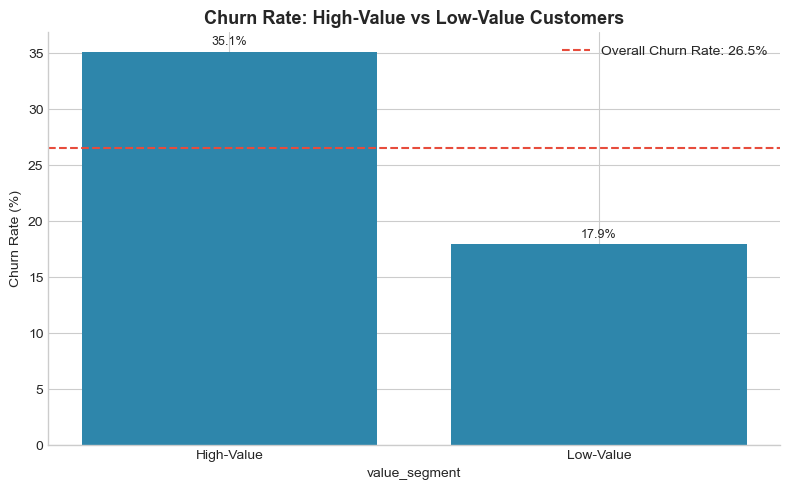

In [57]:
plot_churn_rate(value_summary, "value_segment", "Churn Rate: High-Value vs Low-Value Customers", color='#2E86AB')

#### Observation

High-value customers (above median monthly charge) are expected to show a
higher churn rate than low-value customers, consistent with the pricing
pattern already observed in Section 5.3.

### 5.5.2 New vs Long-Term Customers

#### Objective

Customers are split into New (tenure ≤ 12 months) and Long-Term (tenure > 12
months) segments to quantify the early-tenure churn risk observed in Section
5.2.

In [37]:
df["tenure_segment"] = np.where(df["tenure"] <= 12, "New (≤12 months)", "Long-Term (>12 months)")

tenure_segment_summary = churn_rate_by_category(df, "tenure_segment")
tenure_segment_summary

,tenure_segment,churn_rate,count
1,New (≤12 months),47.44,2186
0,Long-Term (>12 months),17.13,4857


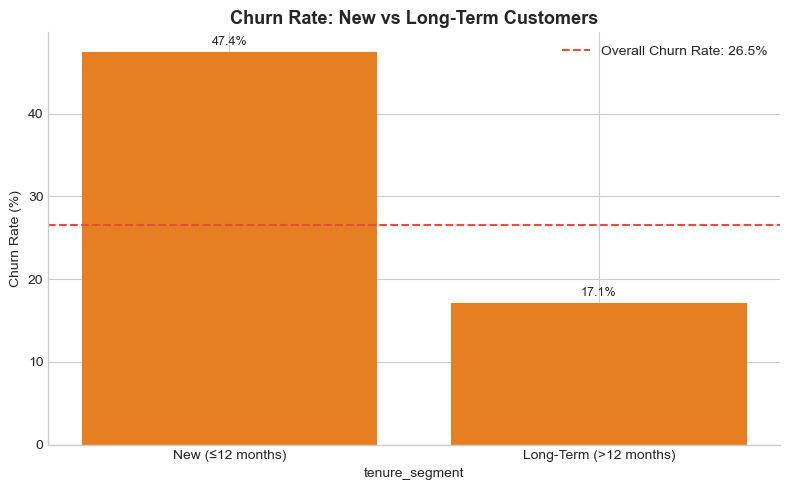

In [58]:
plot_churn_rate(tenure_segment_summary, "tenure_segment", "Churn Rate: New vs Long-Term Customers", color='#E67E22')

#### Observation

New customers (tenure ≤ 12 months) are expected to show a substantially
higher churn rate than long-term customers, confirming that the first year
is the period of highest churn risk.

### 5.5.3 Contract-Based Segments

#### Objective

This section cross-tabulates contract type with the new/long-term tenure
segment to see whether contract type explains churn risk independently of
tenure, or whether the two overlap.

In [39]:
contract_tenure_summary = (
    df
    .groupby(["Contract", "tenure_segment"])["Churn"]
    .value_counts(normalize=True)
    .rename("rate")
    .reset_index()
)

contract_tenure_summary = contract_tenure_summary[contract_tenure_summary["Churn"] == "Yes"].drop(columns="Churn")
contract_tenure_summary["rate"] = round(contract_tenure_summary["rate"] * 100, 2)

contract_tenure_pivot = contract_tenure_summary.pivot(index="Contract", columns="tenure_segment", values="rate")

contract_tenure_pivot

tenure_segment,Long-Term (>12 months),New (≤12 months)
Contract,,
Month-to-month,33.55,51.35
One year,11.34,10.48
Two year,2.95,NaN


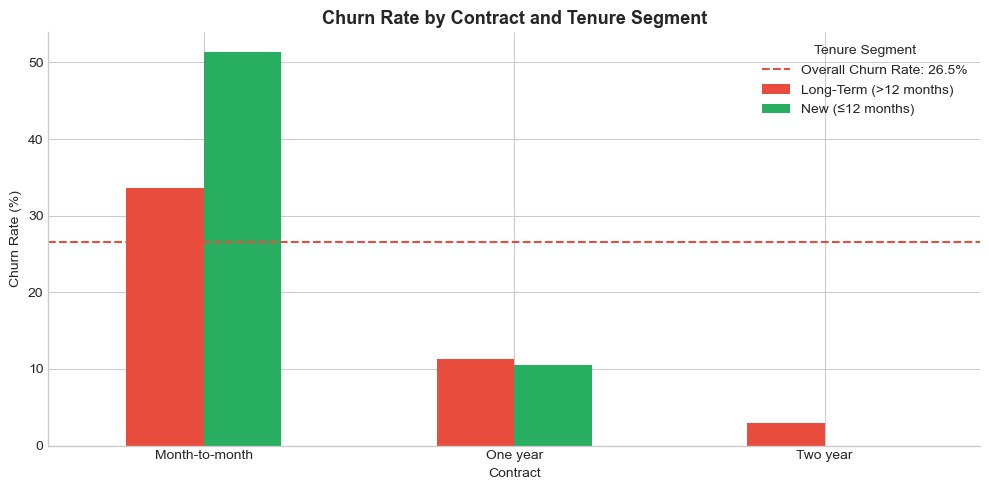

In [40]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 5))

contract_tenure_pivot.plot(kind="bar", ax=ax, color=['#E74C3C', '#27AE60'])

overall_rate = (df["Churn"] == "Yes").mean() * 100
ax.axhline(overall_rate, color='#E74C3C', linestyle='--', linewidth=1.5,
           label=f'Overall Churn Rate: {overall_rate:.1f}%')

ax.set_xlabel("Contract")
ax.set_ylabel("Churn Rate (%)")
ax.set_title("Churn Rate by Contract and Tenure Segment", fontsize=13, fontweight='bold')
plt.xticks(rotation=0)
ax.legend(title="Tenure Segment")
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

#### Observation

New, month-to-month customers are expected to represent the highest-risk
combination by a wide margin, while long-term customers on one- or two-year
contracts are expected to show churn rates close to zero. This indicates
contract type and tenure jointly define the highest-risk segment, rather
than either factor acting independently.

### 5.5.4 Service Adoption Segments

#### Objective

Customers are segmented by how many of the retention-associated add-on
services (online security, online backup, device protection, tech support)
they have subscribed to, to see whether broader service adoption compounds
the retention effect observed individually in Section 5.4.

In [41]:
retention_services = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport"]

df["adopted_services_count"] = (df[retention_services] == "Yes").sum(axis=1)

service_adoption_summary = churn_rate_by_category(df, "adopted_services_count")
service_adoption_summary

,adopted_services_count,churn_rate,count
1,1,38.85,1467
0,0,29.75,2793
2,2,23.76,1372
3,3,12.43,941
4,4,5.32,470


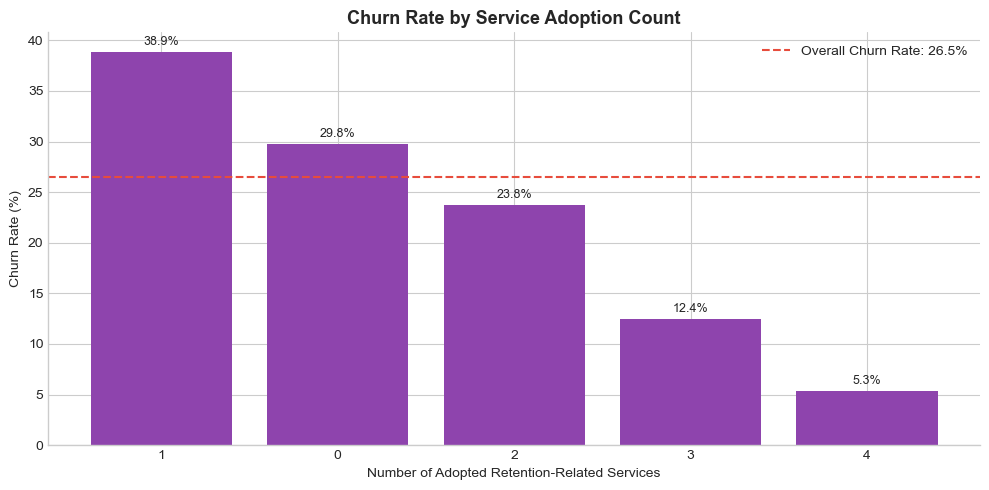

In [42]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(service_adoption_summary["adopted_services_count"].astype(str), service_adoption_summary["churn_rate"], color='#8E44AD')

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%', (bar.get_x() + bar.get_width() / 2, height),
                textcoords="offset points", xytext=(0, 5), ha='center', fontsize=9)

overall_rate = (df["Churn"] == "Yes").mean() * 100
ax.axhline(overall_rate, color='#E74C3C', linestyle='--', linewidth=1.5,
           label=f'Overall Churn Rate: {overall_rate:.1f}%')

ax.set_xlabel("Number of Adopted Retention-Related Services")
ax.set_ylabel("Churn Rate (%)")
ax.set_title("Churn Rate by Service Adoption Count", fontsize=13, fontweight='bold')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

#### Observation

Churn rate is expected to decrease steadily as the number of adopted
retention-related services increases, confirming that service adoption has a
cumulative protective effect rather than being driven by a single service
alone.

#### Summary

Segmentation confirms that churn risk is not evenly distributed: it
concentrates sharply among new, month-to-month, high-charge customers with
low service adoption. Long-term customers on annual contracts with multiple
adopted services represent the lowest-risk segment. These combined segments,
rather than any single factor, define the clearest targets for retention
efforts.

## 5.6 EDA Summary

This section consolidates the findings from all EDA subsections.

#### Customer Profile (5.1)
- Gender shows no meaningful association with churn.
- Senior citizens, customers without a partner, and customers without
  dependents show higher churn rates.

#### Customer Relationship (5.2)
- Churn is concentrated among low-tenure customers.
- Month-to-month contracts show a substantially higher churn rate than
  annual contracts.
- Electronic check payers churn more than customers using automatic payment
  methods.

#### Financial Analysis (5.3)
- Churned customers tend to have higher monthly charges but lower total
  charges — the latter driven by shorter tenure, not lower pricing.

#### Services Analysis (5.4)
- Fiber optic internet is associated with higher churn.
- Security-related add-ons (online security, tech support, online backup,
  device protection) are associated with lower churn; streaming services
  show little effect.

#### Customer Segmentation (5.5)
- Churn risk concentrates sharply in the segment of new, month-to-month,
  high-charge customers with low service adoption.
- Service adoption shows a cumulative protective effect on retention.

#### Overall Takeaway

Churn is not driven by a single factor but by a compounding combination of
short tenure, flexible (month-to-month) contracts, higher pricing, and low
adoption of security/support services. This combination defines the
highest-priority segment for retention efforts, to be tested statistically
in `04_statistical_analysis.ipynb`.